SUPERMARKET SALES PREDICTION

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("SuperMarketAnalysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
print(df.shape)

(1000, 17)


In [3]:
print(df.columns.tolist())

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [4]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
print(df.dtypes)

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [6]:
print(df.isnull().sum())

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5%', 'sales', 'date', 'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'rating']


In [8]:
df

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [9]:
print(df[["unit_price", "quantity", "sales"]].describe())

        unit_price     quantity        sales
count  1000.000000  1000.000000  1000.000000
mean     55.672130     5.510000   322.966749
std      26.494628     2.923431   245.885335
min      10.080000     1.000000    10.678500
25%      32.875000     3.000000   124.422375
50%      55.230000     5.000000   253.848000
75%      77.935000     8.000000   471.350250
max      99.960000    10.000000  1042.650000


In [10]:
X = df[["unit_price", "quantity"]]
y= df["sales"]

In [11]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("First 5 rows of Features:")
print(X.head())
print()
print("First 5 rows of Target:")
print(y.head())

Features shape: (1000, 2)
Target shape: (1000,)

First 5 rows of Features:
   unit_price  quantity
0       74.69         7
1       15.28         5
2       46.33         7
3       58.22         8
4       86.31         7

First 5 rows of Target:
0    548.9715
1     80.2200
2    340.5255
3    489.0480
4    634.3785
Name: sales, dtype: float64


In [12]:

print(df.dtypes)
print()

print(df.duplicated().sum())

invoice_id                  object
branch                      object
city                        object
customer_type               object
gender                      object
product_line                object
unit_price                 float64
quantity                     int64
tax_5%                     float64
sales                      float64
date                        object
time                        object
payment                     object
cogs                       float64
gross_margin_percentage    float64
gross_income               float64
rating                     float64
dtype: object

0


In [13]:
print("Date samples:")
print(df["date"].head(10))
print()
print("Time samples:")
print(df["time"].head(10))

Date samples:
0     1/5/2019
1     3/8/2019
2     3/3/2019
3    1/27/2019
4     2/8/2019
5    3/25/2019
6    2/25/2019
7    2/24/2019
8    1/10/2019
9    2/20/2019
Name: date, dtype: object

Time samples:
0     1:08:00 PM
1    10:29:00 AM
2     1:23:00 PM
3     8:33:00 PM
4    10:37:00 AM
5     6:30:00 PM
6     2:36:00 PM
7    11:38:00 AM
8     5:15:00 PM
9     1:27:00 PM
Name: time, dtype: object


In [14]:
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p")
print(df["time"].dtype)
print(df["time"].head())

datetime64[ns]
0   1900-01-01 13:08:00
1   1900-01-01 10:29:00
2   1900-01-01 13:23:00
3   1900-01-01 20:33:00
4   1900-01-01 10:37:00
Name: time, dtype: datetime64[ns]


In [15]:
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
print(df["date"].dtype)
print(df["date"].head())

datetime64[ns]
0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: date, dtype: datetime64[ns]


In [16]:
df["month"]       = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()
df["hour"]        = df["time"].dt.hour

print(df[["date", "month", "day_of_week", "hour"]].head())

        date  month day_of_week  hour
0 2019-01-05      1    Saturday    13
1 2019-03-08      3      Friday    10
2 2019-03-03      3      Sunday    13
3 2019-01-27      1      Sunday    20
4 2019-02-08      2      Friday    10


In [35]:
df.to_csv("clean_supermarket.csv", index=False)
print("Saved successfully!")

Saved successfully!


 After Cleaning 2 - MATPLOTLIB VISUALIZATIONS

In [ ]:
df = pd.read_csv("clean_supermarket.csv")
print(df.shape)
df.head()

(1000, 20)


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,month,day_of_week,hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,1,Saturday,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,3,Friday,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,Sunday,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,1,Sunday,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2,Friday,10


 SECTION 1 - SALES PERFORMANCE

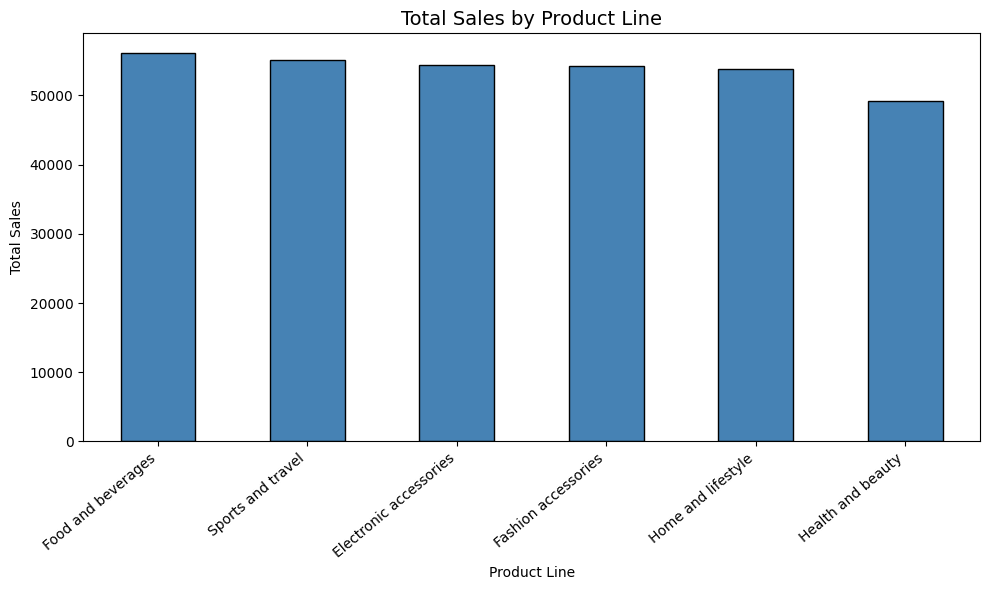

Best Product Line: Food and beverages


In [ ]:
# Chart 1 - Which product line generates highest sales?

df.groupby("product_line")["sales"].sum().sort_values(ascending=False).plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10,6))
plt.title("Total Sales by Product Line", fontsize=14)
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Best Product Line:", df.groupby("product_line")["sales"].sum().idxmax())

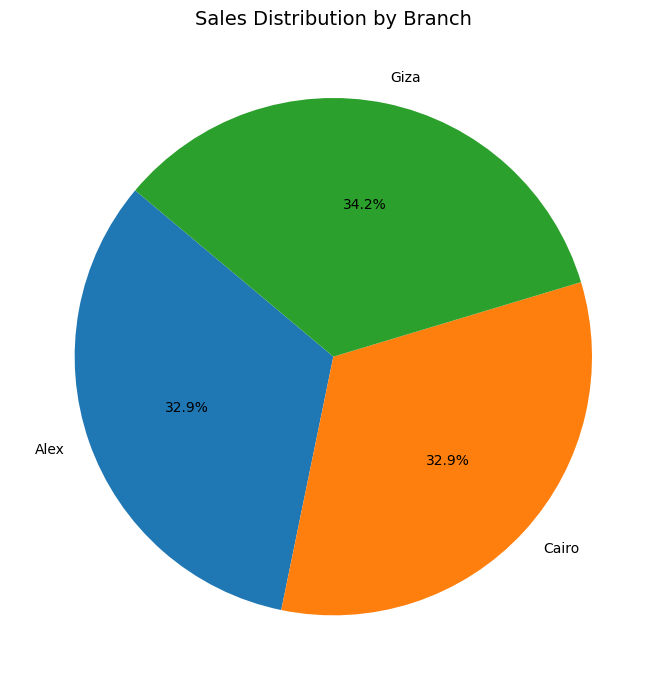

Best Branch: Giza


In [ ]:
# Chart 2 - Which branch has highest sales?

branch_sales = df.groupby("branch")["sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(branch_sales.values, labels=branch_sales.index, autopct="%1.1f%%", startangle=140)
plt.title("Sales Distribution by Branch", fontsize=14)
plt.tight_layout()
plt.show()

print("Best Branch:", branch_sales.idxmax())

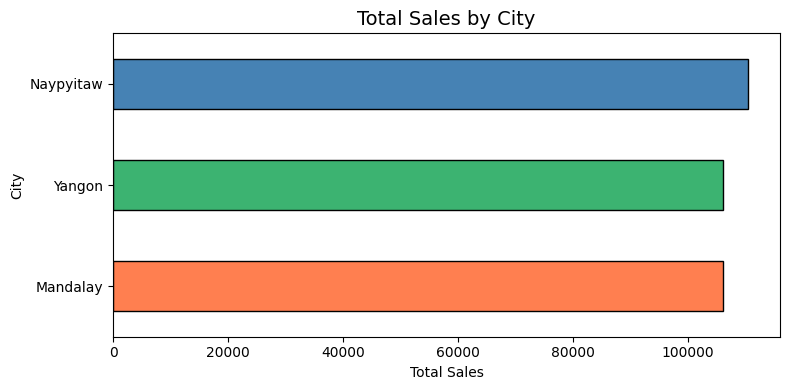

Best City: Naypyitaw


In [ ]:
# Chart 3 - Which city has highest sales?

df.groupby("city")["sales"].sum().sort_values().plot(kind="barh", color=["coral","mediumseagreen","steelblue"], edgecolor="black", figsize=(8,4))
plt.title("Total Sales by City", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

print("Best City:", df.groupby("city")["sales"].sum().idxmax())

SECTION 2 - CUSTOMER ANALYSIS

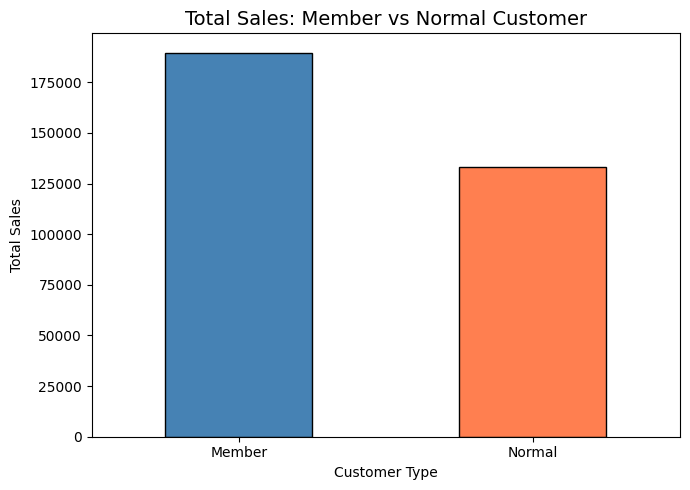

Top Customer Type: Member


In [ ]:
# Chart 4 - Do members spend more than normal customers?

df.groupby("customer_type")["sales"].sum().plot(kind="bar", color=["steelblue","coral"], edgecolor="black", figsize=(7,5))
plt.title("Total Sales: Member vs Normal Customer", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Top Customer Type:", df.groupby("customer_type")["sales"].sum().idxmax())

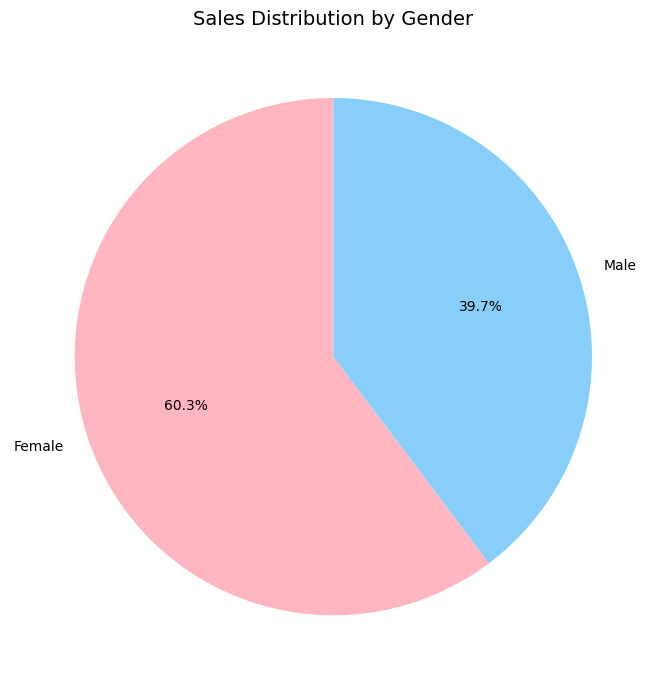

Top Gender: Female


In [ ]:
# Chart 5 - Do male or female customers spend more?

gender_sales = df.groupby("gender")["sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(gender_sales.values, labels=gender_sales.index, autopct="%1.1f%%", colors=["lightpink","lightskyblue"], startangle=90)
plt.title("Sales Distribution by Gender", fontsize=14)
plt.tight_layout()
plt.show()

print("Top Gender:", gender_sales.idxmax())

SECTION 3 - PAYMENT ANALYSIS

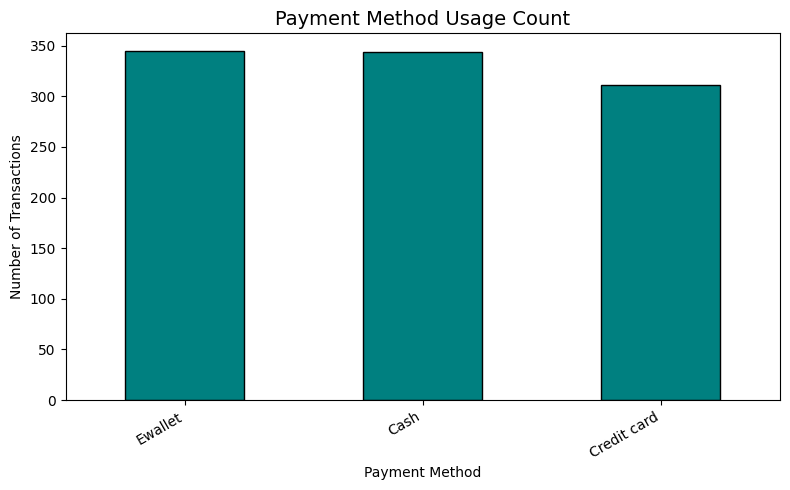

Most Used Payment: Ewallet


In [ ]:
# Chart 6 - Which payment method is used most?

df["payment"].value_counts().plot(kind="bar", color="teal", edgecolor="black", figsize=(8,5))
plt.title("Payment Method Usage Count", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Most Used Payment:", df["payment"].value_counts().idxmax())

SECTION 4 - RATING ANALYSIS

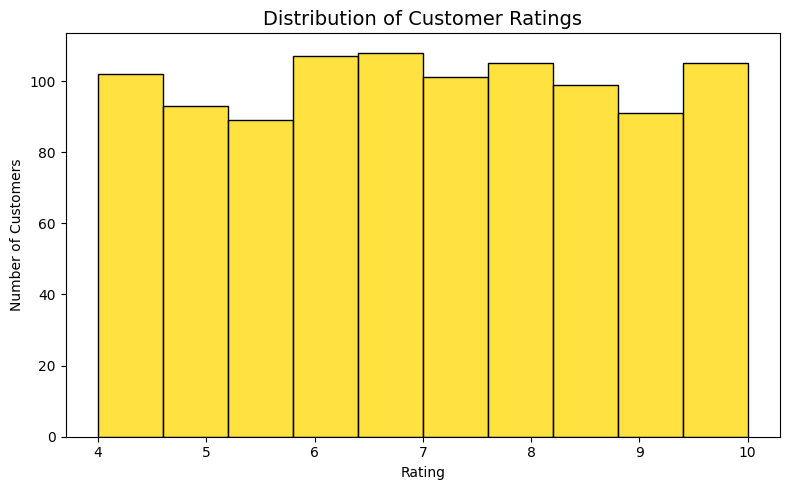

Average Rating : 6.97
Highest Rating : 10.0
Lowest Rating  : 4.0


In [ ]:
# Chart 7 - How are customer ratings distributed?

plt.figure(figsize=(8, 5))
sns.histplot(df["rating"], bins=10, color="gold")
plt.title("Distribution of Customer Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print(f"Average Rating : {df['rating'].mean():.2f}")
print(f"Highest Rating : {df['rating'].max()}")
print(f"Lowest Rating  : {df['rating'].min()}")

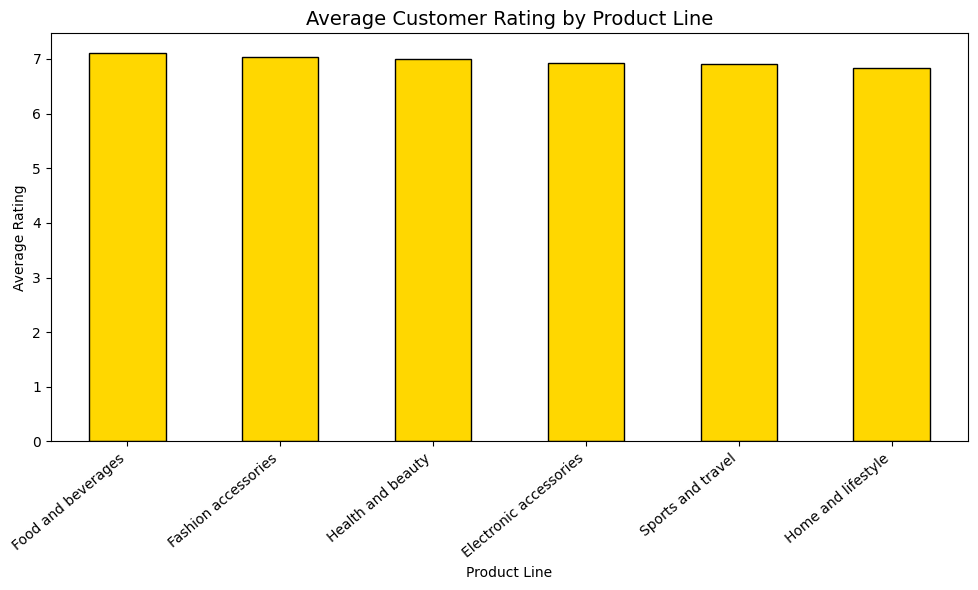

Highest Rated: Food and beverages
Lowest Rated : Home and lifestyle


In [ ]:
# Chart 8 - Which product line gets best ratings?

df.groupby("product_line")["rating"].mean().sort_values(ascending=False).plot(kind="bar", color="gold", edgecolor="black", figsize=(10,6))
plt.title("Average Customer Rating by Product Line", fontsize=14)
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Highest Rated:", df.groupby("product_line")["rating"].mean().idxmax())
print("Lowest Rated :", df.groupby("product_line")["rating"].mean().idxmin())

 SECTION 5 - PROFIT ANALYSIS

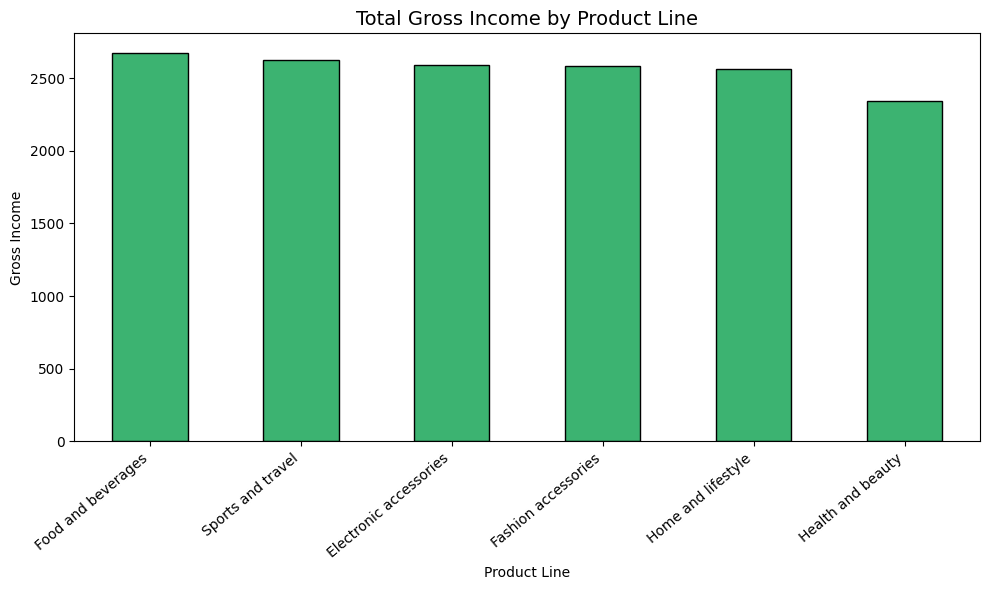

Most Profitable: Food and beverages


In [ ]:

# Chart 9 - Which product line earns most profit?

df.groupby("product_line")["gross_income"].sum().sort_values(ascending=False).plot(kind="bar", color="mediumseagreen", edgecolor="black", figsize=(10,6))
plt.title("Total Gross Income by Product Line", fontsize=14)
plt.xlabel("Product Line")
plt.ylabel("Gross Income")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Most Profitable:", df.groupby("product_line")["gross_income"].sum().idxmax())

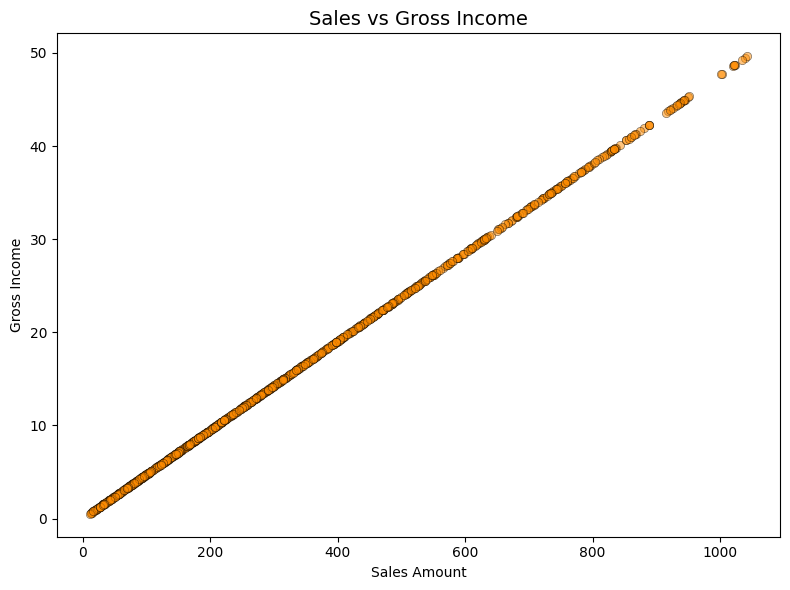

INSIGHT: Dots going upward = higher sales means higher profit


In [ ]:
# Chart 10 - Does higher sales always mean higher profit?

plt.figure(figsize=(8, 6))
plt.scatter(df["sales"], df["gross_income"], color="darkorange", alpha=0.5, edgecolors="black", linewidths=0.5)
plt.title("Sales vs Gross Income", fontsize=14)
plt.xlabel("Sales Amount")
plt.ylabel("Gross Income")
plt.tight_layout()
plt.show()

print("INSIGHT: Dots going upward = higher sales means higher profit")

SECTION 6 - TIME BASED ANALYSIS

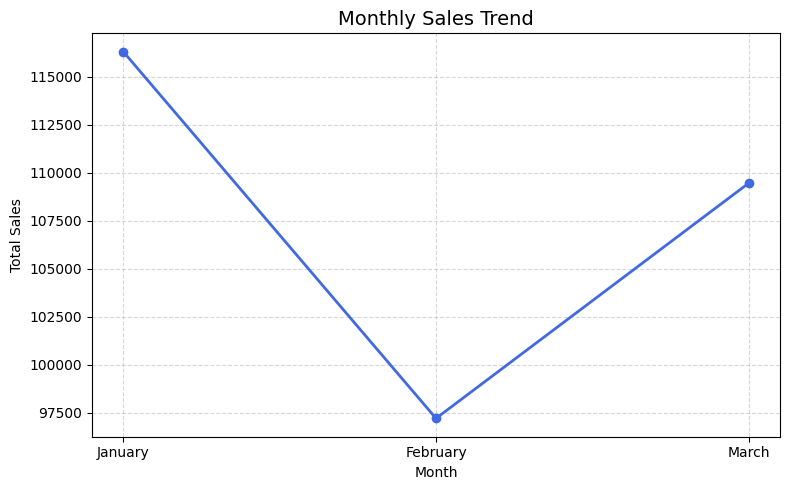

Best Month: 1


In [ ]:
# Chart 11 - Which month has highest sales?

df.groupby("month")["sales"].sum().plot(kind="line", marker="o", color="royalblue", linewidth=2, figsize=(8,5))
plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks([1, 2, 3], ["January", "February", "March"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Best Month:", df.groupby("month")["sales"].sum().idxmax())

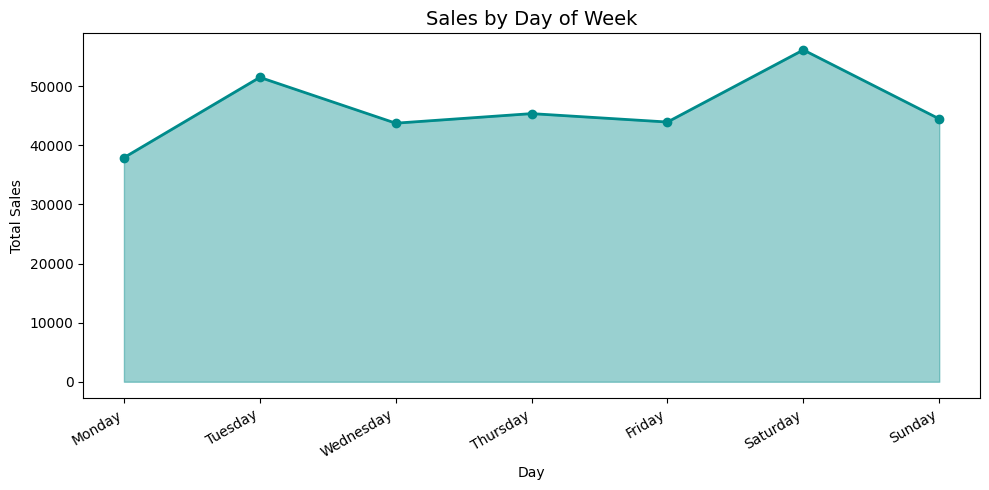

Busiest Day: Saturday


In [ ]:
# Chart 12 - Which day of week has highest sales?

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_sales = df.groupby("day_of_week")["sales"].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.fill_between(range(len(day_sales)), day_sales.values, alpha=0.4, color="darkcyan")
plt.plot(range(len(day_sales)), day_sales.values, marker="o", color="darkcyan", linewidth=2)
plt.title("Sales by Day of Week", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(range(len(day_sales)), day_sales.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Busiest Day:", day_sales.idxmax())

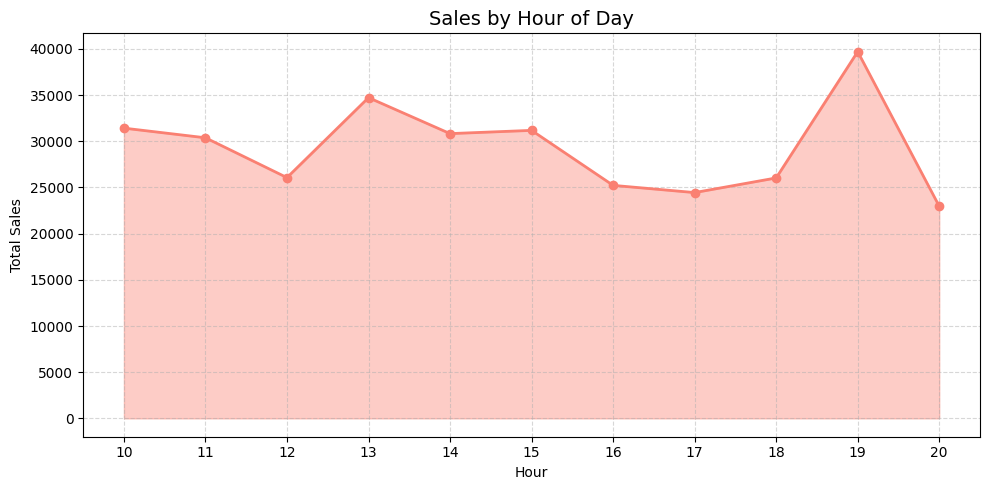

Peak Shopping Hour: 19:00


In [ ]:
# Chart 13 - What time of day are most purchases made?

hourly_sales = df.groupby("hour")["sales"].sum()

plt.figure(figsize=(10, 5))
plt.fill_between(hourly_sales.index, hourly_sales.values, alpha=0.4, color="salmon")
plt.plot(hourly_sales.index, hourly_sales.values, marker="o", color="salmon", linewidth=2)
plt.title("Sales by Hour of Day", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.xticks(hourly_sales.index)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Peak Shopping Hour:", str(df.groupby("hour")["sales"].sum().idxmax()) + ":00")

FINAL SUMMARY AND INSIGHTS

In [ ]:

print("=" * 55)
print("   SUPERMARKET SALES DASHBOARD - FINAL REPORT")
print("=" * 55)
print(f"Total Transactions  : {len(df)}")
print(f"Total Revenue       : {df['sales'].sum():.2f}")
print(f"Total Profit        : {df['gross_income'].sum():.2f}")
print(f"Average Bill Amount : {df['sales'].mean():.2f}")
print(f"Average Rating      : {df['rating'].mean():.2f} / 10")
print()
print("--- TOP FINDINGS ---")
print("Best Product Line  :", df.groupby("product_line")["sales"].sum().idxmax())
print("Best Branch        :", df.groupby("branch")["sales"].sum().idxmax())
print("Best City          :", df.groupby("city")["sales"].sum().idxmax())
print("Top Payment Method :", df["payment"].value_counts().idxmax())
print("Best Customer Type :", df.groupby("customer_type")["sales"].sum().idxmax())
print("Best Month         :", df.groupby("month")["sales"].sum().idxmax())
print("Busiest Day        :", df.groupby("day_of_week")["sales"].sum().idxmax())
print("Peak Hour          :", str(df.groupby("hour")["sales"].sum().idxmax()) + ":00")
print("Highest Rated      :", df.groupby("product_line")["rating"].mean().idxmax())
print("Most Profitable    :", df.groupby("product_line")["gross_income"].sum().idxmax())
print()
print("--- BUSINESS RECOMMENDATIONS ---")
print("1. Stock more of", df.groupby("product_line")["sales"].sum().idxmax(), "- highest revenue")
print("2. Focus on Branch", df.groupby("branch")["sales"].sum().idxmax(), "- top performer")
print("3. Run offers on", df.groupby("day_of_week")["sales"].sum().idxmax(), "- busiest day")
print("4. Launch deals at", str(df.groupby("hour")["sales"].sum().idxmax()) + ":00", "- peak hour")
print("5. Improve service for", df.groupby("product_line")["rating"].mean().idxmin(), "- lowest rated")
print("=" * 55)

   SUPERMARKET SALES DASHBOARD - FINAL REPORT
Total Transactions  : 1000
Total Revenue       : 322966.75
Total Profit        : 15379.37
Average Bill Amount : 322.97
Average Rating      : 6.97 / 10

--- TOP FINDINGS ---
Best Product Line  : Food and beverages
Best Branch        : Giza
Best City          : Naypyitaw
Top Payment Method : Ewallet
Best Customer Type : Member
Best Month         : 1
Busiest Day        : Saturday
Peak Hour          : 19:00
Highest Rated      : Food and beverages
Most Profitable    : Food and beverages

--- BUSINESS RECOMMENDATIONS ---
1. Stock more of Food and beverages - highest revenue
2. Focus on Branch Giza - top performer
3. Run offers on Saturday - busiest day
4. Launch deals at 19:00 - peak hour
5. Improve service for Home and lifestyle - lowest rated


ML MODEL - SALES PREDICTION
USING LINEAR REGRESSION

In [21]:
# X = Input we give to model
# y = Output we want model to predict

X = df[["unit_price", "quantity"]]
y = df["sales"]

In [22]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("First 5 rows of X:")
print(X.head())
print()
print("First 5 rows of y:")
print(y.head())

Features shape: (1000, 2)
Target shape: (1000,)

First 5 rows of X:
   unit_price  quantity
0       74.69         7
1       15.28         5
2       46.33         7
3       58.22         8
4       86.31         7

First 5 rows of y:
0    548.9715
1     80.2200
2    340.5255
3    489.0480
4    634.3785
Name: sales, dtype: float64


In [23]:
# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
print("Total rows    :", len(df))
print("Training rows :", len(X_train))
print("Testing rows  :", len(X_test))

Total rows    : 1000
Training rows : 800
Testing rows  : 200


In [25]:
# Create a blank Linear Regression model
model = LinearRegression()

In [26]:
# Train the model on training data
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [ ]:
print("Coefficient for unit_price :", model.coef_[0])
print("Coefficient for quantity   :", model.coef_[1])
print("Intercept                  :", model.intercept_)

Coefficient for unit_price : 5.797957697879609
Coefficient for quantity   : 58.243055361850594
Intercept                  : -322.15986610295266


In [28]:
# Model predicts sales on test data
y_pred = model.predict(X_test)
print("Predictions done!")
print("First 5 predictions:", y_pred[:5].round(2))

Predictions done!
First 5 predictions: [509.51 600.96 407.97 101.71 -78.87]


In [29]:
#comparing actual vs predict sales
comparison = pd.DataFrame({
    "Actual Sales"   : y_test.values[:10],
    "Predicted Sales": y_pred[:10].round(2),
    "Difference"     : (y_test.values[:10] - y_pred[:10]).round(2)
})
print(comparison)

   Actual Sales  Predicted Sales  Difference
0      523.9710           509.51       14.46
1      616.9800           600.96       16.02
2      408.7335           407.97        0.77
3      135.3555           101.71       33.65
4       45.9270           -78.87      124.80
5      618.9750           602.06       16.91
6      127.8270           147.25      -19.42
7      731.6925           662.73       68.96
8      450.1035           478.18      -28.08
9      138.1275           121.60       16.53


In [ ]:
#printing accuracy report
r2   = r2_score(y_test, y_pred)
print("=" * 40)
print("     MODEL ACCURACY REPORT")
print("=" * 40)
print("R2   :", round(r2, 4))
print("Model Accuracy :", round(r2 * 100, 2), "%")
print("=" * 40)

     MODEL ACCURACY REPORT
R2   : 0.9043
Model Accuracy : 90.43 %


In [31]:
# Change these values and see the prediction!
test_unit_price = 50.0
test_quantity   = 3
my_prediction   = model.predict([[test_unit_price, test_quantity]])

print("Unit Price      :", test_unit_price)
print("Quantity        :", test_quantity)
print("Predicted Sales :", round(my_prediction[0], 2))

Unit Price      : 50.0
Quantity        : 3
Predicted Sales : 142.47


C:\Users\Kritika\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print("=" * 50)
print("         ML MODEL SUMMARY")
print("=" * 50)
print("Model Type     : Linear Regression")
print("ML Type        : Supervised Learning → Regression")
print("Features       : Unit Price, Quantity")
print("Target         : Sales Amount")
print("Training Rows  :", len(X_train))
print("Testing Rows   :", len(X_test))
print("R2 Accuracy    :", round(r2 * 100, 2), "%")

print()
if r2 >= 0.9:
    print("Model Performance : EXCELLENT ")
elif r2 >= 0.7:
    print("Model Performance : GOOD ")
elif r2 >= 0.5:
    print("Model Performance : AVERAGE ")
else:
    print("Model Performance : NEEDS IMPROVEMENT ")
print("=" * 50)

         ML MODEL SUMMARY
Model Type     : Linear Regression
ML Type        : Supervised Learning → Regression
Features       : Unit Price, Quantity
Target         : Sales Amount
Training Rows  : 800
Testing Rows   : 200
R2 Accuracy    : 90.43 %

Model Performance : EXCELLENT 
